# Data process output for Taylor Diagram & Wasserstein-Taylor Diagram

- Load different models (MLP, EBM, Lr, etc.) prediction on convective cloud fractions.
- Load ground truth (CONUS404) convective cloud fraction.
- Output (one-day) flattened data for Taylor diagram analysis.

**Hungjui – 20260601**


In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [2]:
import time
import datetime as dt

import numpy as np
import xarray as xr
import pandas as pd

***
## Load saved prediction datasets:

In [3]:
## Load multiple prediction datasets:

sel_mode = 'freq_Conv'
# sel_mode = "freq_DWCC_mod"

wrf_sim_type = 'CTRL'

ana_year = '2022'
ana_yearmonth_range = ['01', '09']


path_prediction_data_1 = f'/glade/derecho/scratch/hungjui/DATA_prediction_NN_CoarseRes/'
path_prediction_data_2 = f'/glade/derecho/scratch/hungjui/DATA_prediction_EBM_CoarseRes/'
path_prediction_data_3 = f'/glade/derecho/scratch/hungjui/DATA_prediction_EBM_CoarseRes/regional_models/'
path_prediction_data_4 = f'/glade/derecho/scratch/hungjui/DATA_prediction_LR_CoarseRes'


prediction_1_name = f'021_NN_dur_2018_2021_freq_Conv_var16_rmAll90.0'
prediction_2_name = f'MergedEBM_2018_2021_freq_Conv_var16_rmAll90.0'
prediction_3_name = f'EBM_dur_2018_2021_freq_Conv_var16_rmAll90.0_MergedRegions'
prediction_4_name = f'LR_dur_2018_2021_freq_Conv_var16_rmAll90.0'

ds_prediction_1 = xr.open_dataset(f'{path_prediction_data_1}/{prediction_1_name}_prediction_{wrf_sim_type}_{sel_mode}_{ana_year}.nc') 
ds_prediction_2 = xr.open_dataset(f'{path_prediction_data_2}/{prediction_2_name}_prediction_{wrf_sim_type}_{sel_mode}_{ana_year}.nc') 
ds_prediction_3 = xr.open_dataset(f'{path_prediction_data_3}/{prediction_3_name}_prediction_{wrf_sim_type}_{sel_mode}_{ana_year}.nc') 
ds_prediction_4 = xr.open_dataset(f'{path_prediction_data_4}/{prediction_4_name}_prediction_{wrf_sim_type}_{sel_mode}_{ana_year}.nc') 

# da_prediction_1_avg = ds_prediction_1[f'predicted_{sel_mode}'].mean(dim='time') #.sel(time=slice('2022-06-01', '2022-09-30')).mean(dim='time')
# da_prediction_2_avg = ds_prediction_2[f'predicted_{sel_mode}'].mean(dim='time') #.sel(time=slice('2022-06-01', '2022-09-30')).mean(dim='time')
# da_prediction_3_avg = ds_prediction_3[f'predicted_{sel_mode}'].mean(dim='time') #.sel(time=slice('2022-06-01', '2022-09-30')).mean(dim='time')
# da_prediction_4_avg = ds_prediction_4[f'predicted_{sel_mode}'].mean(dim='time') #.sel(time=slice('2022-06-01', '2022-09-30')).mean(dim='time')



In [5]:
ds_prediction_4

<xarray.Dataset> Size: 1GB
Dimensions:              (time: 6552, south_north: 145, west_east: 195)
Coordinates:
  * time                 (time) datetime64[ns] 52kB 2022-01-01 ... 2022-09-30...
    XLAT                 (south_north, west_east) float32 113kB ...
    XLONG                (south_north, west_east) float32 113kB ...
Dimensions without coordinates: south_north, west_east
Data variables:
    predicted_freq_Conv  (time, south_north, west_east) float64 1GB ...

***
## Load ground truth:

In [4]:
ds_ground_truth = xr.open_dataset(f'/glade/derecho/scratch/hungjui/DATA_WRF_CONUS_404_SMode_v1.0/StormMode_Freq_CoarseRes_CTRL/wrf3d_404_{wrf_sim_type[0]}_freq_csmode_{ana_year}{ana_yearmonth_range[0]}_{ana_year}{ana_yearmonth_range[-1]}.nc')

# da_ground_truth = ds_ground_truth[sel_mode]
# da_ground_truth

***
## Flatten and Output:
- at a hourly snapshot

In [ ]:
# specific_time = np.datetime64('2022-03-22T00:00:00')
specific_time = np.datetime64('2022-08-22T02:00:00')
# specific_time = np.datetime64('2022-05-13T00:00:00')
# specific_time = np.datetime64('2022-04-10T15:00:00')

specific_time_str = specific_time.astype(dt.datetime).strftime('%Y%m%d%H')

print(specific_time_str)

In [ ]:
da_ground_truth = ds_ground_truth[sel_mode].sel(time=specific_time, method='nearest')

da_prediction_1 = ds_prediction_1[f'predicted_{sel_mode}'].sel(time=specific_time, method='nearest')
da_prediction_2 = ds_prediction_2[f'predicted_{sel_mode}'].sel(time=specific_time, method='nearest')
da_prediction_3 = ds_prediction_3[f'predicted_{sel_mode}'].sel(time=specific_time, method='nearest')
da_prediction_4 = ds_prediction_4[f'predicted_{sel_mode}'].sel(time=specific_time, method='nearest')

da_ground_truth #.plot()

In [ ]:
XLAT_flat = da_ground_truth.XLAT.values.ravel()
XLONG_flat = da_ground_truth.XLONG.values.ravel()

df_flat = pd.DataFrame({ 'XLAT': XLAT_flat, 'XLONG': XLONG_flat })

df_flat['CONUS404'] = da_ground_truth.values.ravel()
df_flat['MLP'] = da_prediction_1.values.ravel()
df_flat['EBM'] = da_prediction_2.values.ravel()
df_flat['EBMregion'] = da_prediction_3.values.ravel()
df_flat['LR'] = da_prediction_3.values.ravel()

df_flat

In [ ]:
df_flat.to_parquet('./Data/caig_model_eval.parquet', index=False)

***
## Flatten and Output:
- at a grid point

In [10]:
def find_nearest_index(ds, target_lat, target_lon):
    
    lat = ds.XLAT.values
    lon = ds.XLONG.values
    dist = np.sqrt((lat - target_lat)**2 + (lon - target_lon)**2)
    south_idx, west_idx = np.unravel_index(dist.argmin(), dist.shape)
    
    return south_idx, west_idx
    

In [13]:
target_lon = -107
target_lat = 25

south_idx, west_idx = find_nearest_index(ds_ground_truth, target_lat, target_lon)

print(south_idx, west_idx)


18 64


In [16]:
da_ground_truth = ds_ground_truth[sel_mode].sel(south_north=south_idx, west_east=west_idx)

da_prediction_1 = ds_prediction_1[f'predicted_{sel_mode}'].sel(south_north=south_idx, west_east=west_idx)
da_prediction_2 = ds_prediction_2[f'predicted_{sel_mode}'].sel(south_north=south_idx, west_east=west_idx)
da_prediction_3 = ds_prediction_3[f'predicted_{sel_mode}'].sel(south_north=south_idx, west_east=west_idx)
da_prediction_4 = ds_prediction_4[f'predicted_{sel_mode}'].sel(south_north=south_idx, west_east=west_idx)

In [18]:
df_flat = pd.DataFrame({ 'time': ds_ground_truth['time'].values })

df_flat['CONUS404'] = da_ground_truth.values.ravel()
df_flat['MLP'] = da_prediction_1.values.ravel()
df_flat['EBM'] = da_prediction_2.values.ravel()
df_flat['EBMregion'] = da_prediction_3.values.ravel()
df_flat['LR'] = da_prediction_3.values.ravel()

df_flat

,time,CONUS404,MLP,EBM,EBMregion,LR
0,2022-01-01 00:00:00,2.040816,9.302568,5.895028,3.561842,3.561842
1,2022-01-01 01:00:00,0.000000,13.376979,6.089458,3.587100,3.587100
2,2022-01-01 02:00:00,6.122449,16.556227,5.970848,3.294773,3.294773
3,2022-01-01 03:00:00,0.000000,22.961033,6.050785,4.024079,4.024079
4,2022-01-01 04:00:00,20.408163,22.895885,8.161668,3.791601,3.791601
...,...,...,...,...,...,...
6547,2022-09-30 19:00:00,0.000000,0.212538,2.231233,1.018088,1.018088
6548,2022-09-30 20:00:00,0.000000,0.236317,2.416618,1.133861,1.133861
6549,2022-09-30 21:00:00,0.000000,0.242001,2.464297,1.136294,1.136294
6550,2022-09-30 22:00:00,0.000000,0.526172,2.291457,1.233221,1.233221


In [19]:
df_flat.to_parquet('./Data/caig_model_eval_25N_107W.parquet', index=False)

<Axes: xlabel='time'>

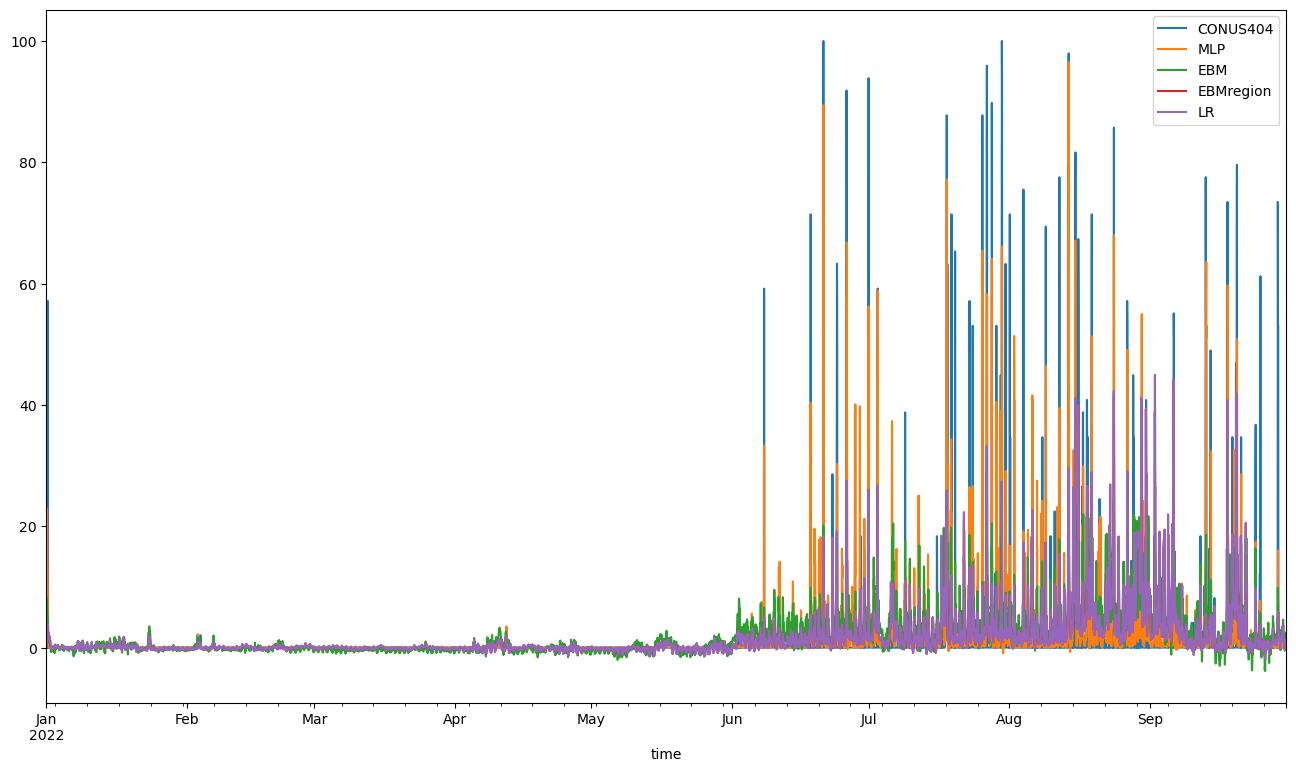

In [24]:
df_flat.set_index('time')[['CONUS404', 'MLP', 'EBM', 'EBMregion', 'LR']].plot(figsize=(16, 9))